# Imports and Setup

In [302]:
# Automatically reload external Python modules when they change
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [303]:
# imports
import matplotlib.pyplot as plt
import pandas as pd

import Functions.load_datasets as load_datasets
import Functions.generate_X as gen_X
import Functions.generate_y as gen_y
import Functions.train_models as train_models
import Functions.plot_ROC as plot_roc
import Functions.plot_shap as plot_shap
import Functions.plot_bootstrap_metrics as plot_metrics

# Generate Datasets, X_, and y_

In [304]:
datasets = load_datasets.load(noun_acc_dataset = 'Datasets/TMSA_NounAcc_gen_train.xlsx', 
                            clinical_dataset = 'Datasets/Clinical_Data_Baseline.xlsx',
                            linguistic_dataset = 'Datasets/Linguistics_Dataset_gen_train.xlsx',
                            networks_dataset = 'Datasets/Network_Strength_Dataset_gen_train.xlsx')

noun_acc_dataset = datasets['noun_acc_dataset']
clinical_dataset = datasets['clinical_dataset']
linguistic_dataset = datasets['linguistic_dataset']
networks_dataset = datasets['networks_dataset']

Loaded Datasets/TMSA_NounAcc_gen_train.xlsx, shape: (4620, 7)
Loaded Datasets/Clinical_Data_Baseline.xlsx, shape: (38, 17)
Loaded Datasets/Linguistics_Dataset_gen_train.xlsx, shape: (66, 8)
Loaded Datasets/Network_Strength_Dataset_gen_train.xlsx, shape: (35, 84)


In [305]:
datasets = gen_X.merge_datasets(noun_acc_dataset, clinical_dataset, linguistic_dataset, networks_dataset)
X_processed = gen_X.generate_X(datasets)

clin: (4488, 23) rows, columns: ['SubjID', 'Baseline', 'Trial', 'Card', 'Agent_Noun', 'Noun_Acc', 'Item_Type', 'MPO', 'Yrs Edu', 'Age', 'Travel solo', 'Sex', 'Race', 'Ethnicity ', 'Handed', 'CCRSA', 'SS_WAB_Avg', 'AVC_WAB_Avg', 'NWF_WAB_Avg', 'Diff_WAB_AQ', 'Avg_WAB_AQ ', 'Aphasia_Type_1', 'Lesion_Volume']
ling: (4620, 14) rows, columns: ['SubjID', 'Baseline', 'Trial', 'Card', 'Agent_Noun', 'Noun_Acc', 'Item_Type', 'Freq_Cond', 'NA_Cond', 'Noun_Freq', 'Noun_NA', 'Syllables_avg (SyllaPy)', 'Phonemes_avg (CMUDict)', 'Morphemes']
nets: (4620, 90) rows, columns: ['SubjID', 'Baseline', 'Trial', 'Card', 'Agent_Noun', 'Noun_Acc', 'Item_Type', 'R_lateralorbitofrontal', 'R_parsorbitalis', 'R_frontalpole', 'R_medialorbitofrontal', 'R_parstriangularis', 'R_parsopercularis', 'R_rostralmiddlefrontal', 'R_superiorfrontal', 'R_caudalmiddlefrontal', 'R_precentral', 'R_paracentral', 'R_rostralanteriorcingulate', 'R_caudalanteriorcingulate', 'R_posteriorcingulate', 'R_isthmuscingulate', 'R_postcentral',

In [306]:
X_clin = X_processed['clin']
X_ling = X_processed['ling']
X_nets = X_processed['nets']
X_clin_nets = X_processed['clin_nets']
X_ling_nets = X_processed['ling_nets']
X_clin_ling = X_processed['clin_ling']
X_all3 = X_processed['all3']

In [307]:
y_clin = gen_y.generate_y(datasets['clin'])
y_ling = gen_y.generate_y(datasets['ling'])
y_nets = gen_y.generate_y(datasets['nets'])
y_clin_nets = gen_y.generate_y(datasets['clin_nets'])
y_ling_nets = gen_y.generate_y(datasets['ling_nets'])
y_clin_ling = gen_y.generate_y(datasets['clin_ling'])
y_all3 = gen_y.generate_y(datasets['all3'])


In [308]:
X_clin_ling.columns

Index(['MPO', 'Yrs Edu', 'Age', 'CCRSA', 'SS_WAB_Avg', 'AVC_WAB_Avg',
       'NWF_WAB_Avg', 'Avg_WAB_AQ ', 'Lesion_Volume', 'Freq_Cond', 'NA_Cond',
       'Noun_Freq', 'Noun_NA', 'Syllables_avg (SyllaPy)',
       'Phonemes_avg (CMUDict)', 'Morphemes'],
      dtype='object')

# Train Models

## Clin

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/valida

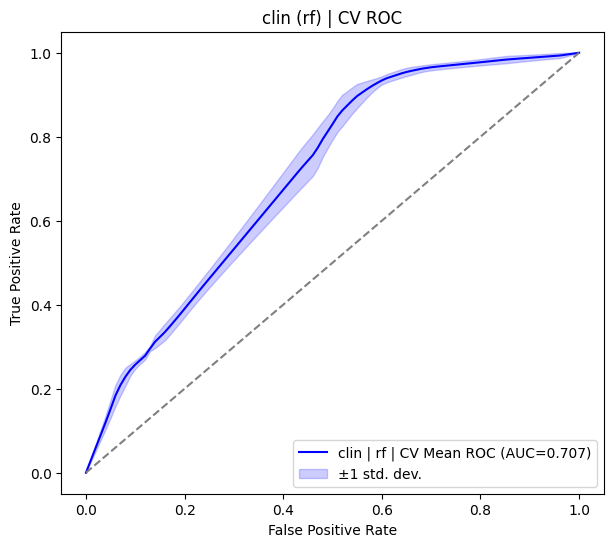

✅ Model saved to: saved_models/clin_rf_best_model.joblib
clin | rf | Test accuracy: 0.734, Test AUC: 0.776


In [309]:
best_rf_clin, rf_metrics_clin, X_test_clin, y_test_clin = train_models.train_and_kfold_validate(
    X_clin, y_clin, model_type='rf', name='clin', param_search=True, random_state=42
)

In [310]:
top_features_RF_clin, shap_vals_RF_clin, explainer_RF_clin = plot_shap.get_top_shap_features(
                                                                    X_clin, 
                                                                    best_rf_clin, 
                                                                    n_features=15, 
                                                                    model_name="RF_clin")


Top 15 Features by Mean |SHAP| Value — RF_clin
NWF_WAB_Avg     0.1299
Avg_WAB_AQ      0.0452
Age             0.0272
AVC_WAB_Avg     0.0173
Yrs Edu         0.0109
SS_WAB_Avg      0.0028
Lesion_Volume   0.0012
MPO             0.0009
CCRSA           0.0006


In [311]:
plot_shap.plot_shap(
    X_clin,
    shap_vals_RF_clin,
    top_features_RF_clin,
    model_name="RF_clin",
    save_path="shap_plots/RF_clin.png"
)


Generating SHAP beeswarm for RF_clin...


/Users/arnavgupta/Documents/Arnav ML Baseline Aphasia/TMSA Training RF Models/Functions/plot_shap.py:176: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Beeswarm saved to shap_plots/RF_clin.png


## Ling

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/valida

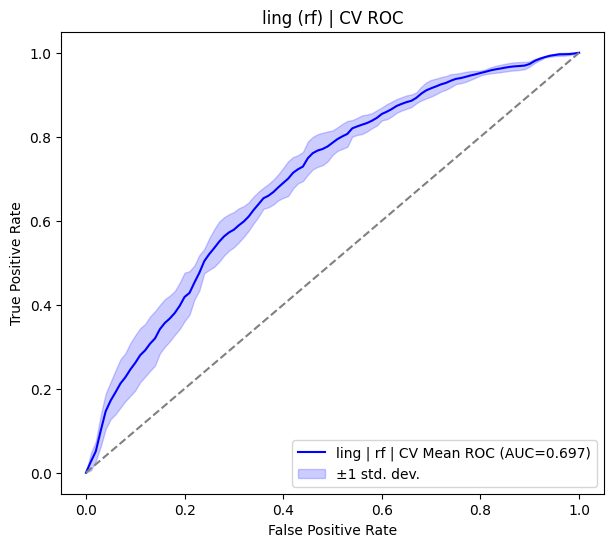

✅ Model saved to: saved_models/ling_rf_best_model.joblib
ling | rf | Test accuracy: 0.740, Test AUC: 0.719


In [312]:
best_rf_ling, rf_metrics_ling, X_test_ling, y_test_ling = train_models.train_and_kfold_validate(
    X_ling, y_ling, model_type='rf', name='ling', param_search=True, random_state=42
)

In [ ]:
top_features_RF_ling, shap_vals_RF_ling, explainer_RF_ling = plot_shap.get_top_shap_features(
                                                                    X_ling, 
                                                                    best_rf_ling, 
                                                                    n_features=15, 
                                                                    model_name="RF_ling")

AttributeError: module 'Functions.plot_shap' has no attribute 'train_and_kfold_validate'

In [ ]:
plot_shap.plot_shap(
    X_ling,
    shap_vals_RF_ling,
    top_features_RF_ling,
    model_name="RF_ling",
    save_path="shap_plots/RF_ling.png"
)


Generating SHAP beeswarm for RF_ling...


/Users/arnavgupta/Documents/Arnav ML Baseline Aphasia/TMSA Training RF Models/Functions/plot_shap.py:176: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Beeswarm saved to shap_plots/RF_ling.png


## Nets

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/valida

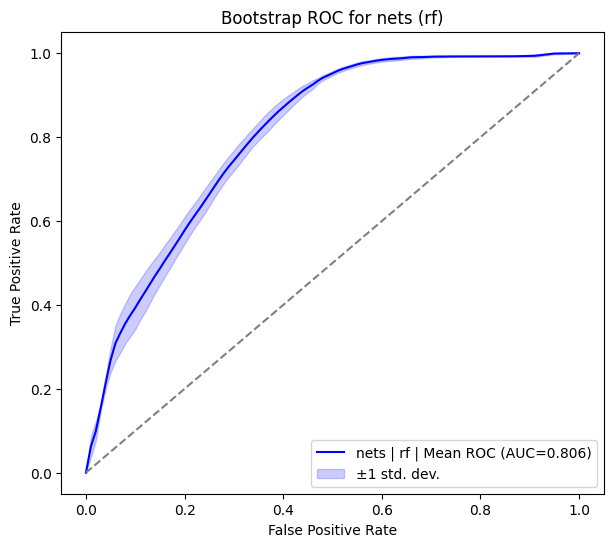

nets | rf | Bootstrap accuracy: 0.753 ± 0.013
✅ Model saved to: saved_models/nets_rf_best_model.joblib


In [ ]:
best_rf_nets, rf_metrics_nets, X_test_nets, y_test_nets = train_models.train_and_kfold_validate(
    X_nets, y_nets, model_type='rf', name='nets', param_search=True, n_jobs=-1, random_state=42
)

In [ ]:
top_features_RF_nets, shap_vals_RF_nets, explainer_RF_nets = plot_shap.get_top_shap_features(
                                                                    X_nets, 
                                                                    best_rf_nets, 
                                                                    n_features=15, 
                                                                    model_name="RF_nets")


Top 15 Features by Mean |SHAP| Value — RF_nets
L_superiorfrontal       0.0598
R_cuneus                0.0563
R_middletemporal        0.0183
L_postcentral           0.0104
L_insula                0.0104
R_thalamusproper        0.0097
R_caudate               0.0092
L_inferiortemporal      0.0083
R_precuneus             0.0083
L_middletemporal        0.0064
L_inferiorparietal      0.0040
R_accumbensarea         0.0038
R_medialorbitofrontal   0.0036
L_parahippocampal       0.0032
R_lingual               0.0031


In [ ]:
plot_shap.plot_shap(
    X_nets,
    shap_vals_RF_nets,
    top_features_RF_nets,
    model_name="RF_nets",
    save_path="shap_plots/RF_nets.png"
)


Generating SHAP beeswarm for RF_nets...


/Users/arnavgupta/Documents/Arnav ML Baseline Aphasia/TMSA Training RF Models/Functions/plot_shap.py:176: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Beeswarm saved to shap_plots/RF_nets.png


## Clin_Nets

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/valida

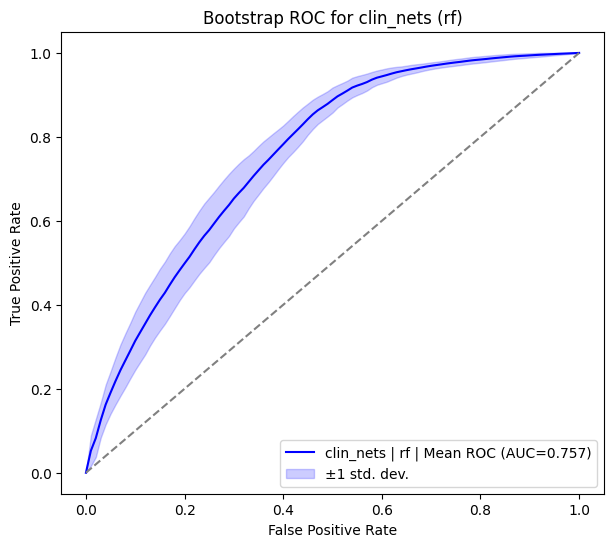

clin_nets | rf | Bootstrap accuracy: 0.721 ± 0.021
✅ Model saved to: saved_models/clin_nets_rf_best_model.joblib


In [ ]:
best_rf_clin_nets, rf_metrics_clin_nets, X_test_clin_nets, y_test_clin_nets = train_models.train_and_kfold_validate(
    X_clin_nets, y_clin_nets, model_type='rf', name='clin_nets', param_search=True, random_state=42
)

In [ ]:
top_features_RF_clin_nets, shap_vals_RF_clin_nets, explainer_RF_clin_nets = plot_shap.get_top_shap_features(
                                                                    X_clin_nets, 
                                                                    best_rf_clin_nets, 
                                                                    n_features=15, 
                                                                    model_name="RF_clin_nets")


Top 15 Features by Mean |SHAP| Value — RF_clin_nets
AVC_WAB_Avg          0.0178
Avg_WAB_AQ           0.0163
NWF_WAB_Avg          0.0161
SS_WAB_Avg           0.0147
Age                  0.0131
L_superiorfrontal    0.0096
R_cuneus             0.0070
R_paracentral        0.0063
L_parahippocampal    0.0062
R_lateraloccipital   0.0055
R_isthmuscingulate   0.0053
R_inferiortemporal   0.0042
R_precuneus          0.0039
R_middletemporal     0.0037
L_amygdala           0.0036


In [ ]:
plot_shap.plot_shap(
    X_clin_nets,
    shap_vals_RF_clin_nets,
    top_features_RF_clin_nets,
    model_name="RF_clin_nets",
    save_path="shap_plots/RF_clin_nets.png"
)


Generating SHAP beeswarm for RF_clin_nets...


/Users/arnavgupta/Documents/Arnav ML Baseline Aphasia/TMSA Training RF Models/Functions/plot_shap.py:176: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Beeswarm saved to shap_plots/RF_clin_nets.png


## Ling_Nets

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/valida

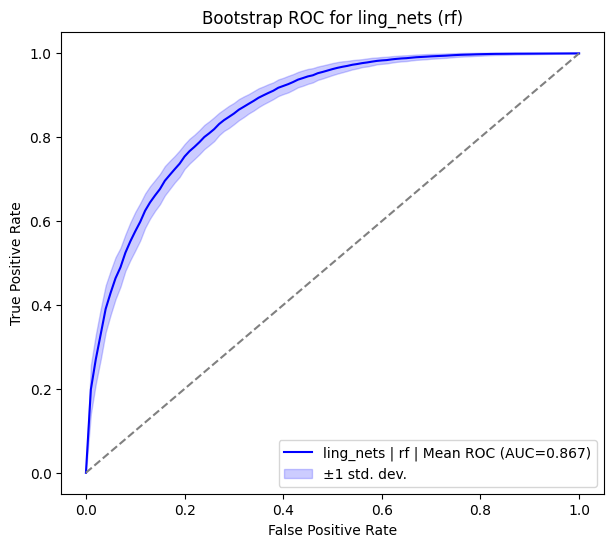

ling_nets | rf | Bootstrap accuracy: 0.804 ± 0.013
✅ Model saved to: saved_models/ling_nets_rf_best_model.joblib


In [ ]:
best_rf_ling_nets, rf_metrics_ling_nets, X_test_ling_nets, y_test_ling_nets = train_models.train_and_kfold_validate(
    X_ling_nets, y_ling_nets, model_type='rf', name='ling_nets', param_search=True, random_state=42
)

In [ ]:
top_features_RF_ling_nets, shap_vals_RF_ling_nets, explainer_RF_ling_nets = plot_shap.get_top_shap_features(
                                                                    X_ling_nets, 
                                                                    best_rf_ling_nets, 
                                                                    n_features=15, 
                                                                    model_name="RF_ling_nets")


Top 15 Features by Mean |SHAP| Value — RF_ling_nets
Noun_Freq                 0.0760
L_superiorfrontal         0.0602
Noun_NA                   0.0578
R_cuneus                  0.0518
Phonemes_avg (CMUDict)    0.0292
Syllables_avg (SyllaPy)   0.0172
R_middletemporal          0.0133
Morphemes                 0.0128
L_postcentral             0.0119
R_precuneus               0.0111
L_inferiortemporal        0.0098
R_thalamusproper          0.0090
L_middletemporal          0.0085
R_caudate                 0.0081
R_accumbensarea           0.0067


In [ ]:
plot_shap.plot_shap(
    X_ling_nets,
    shap_vals_RF_ling_nets,
    top_features_RF_ling_nets,
    model_name="RF_ling_nets",
    save_path="shap_plots/RF_ling_nets.png"
)


Generating SHAP beeswarm for RF_ling_nets...


/Users/arnavgupta/Documents/Arnav ML Baseline Aphasia/TMSA Training RF Models/Functions/plot_shap.py:176: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Beeswarm saved to shap_plots/RF_ling_nets.png


## Clin_Ling

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/valida

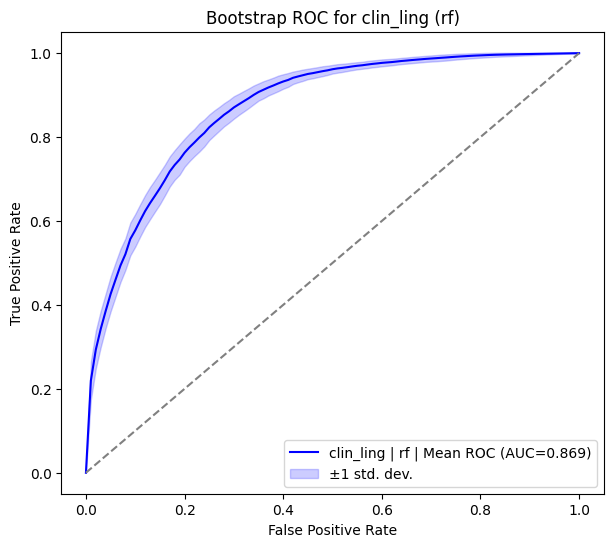

clin_ling | rf | Bootstrap accuracy: 0.801 ± 0.012
✅ Model saved to: saved_models/clin_ling_rf_best_model.joblib


In [ ]:
best_rf_clin_ling, rf_metrics_clin_ling, X_test_clin_ling, y_test_clin_ling = train_models.train_and_kfold_validate(
    X_clin_ling, y_clin_ling, model_type='rf', name='clin_ling', param_search=True, random_state=42
)

In [ ]:
top_features_RF_clin_ling, shap_vals_RF_clin_ling, explainer_RF_clin_ling = plot_shap.get_top_shap_features(
                                                                    X_clin_ling, 
                                                                    best_rf_clin_ling, 
                                                                    n_features=15, 
                                                                    model_name="RF_clin_ling")


Top 15 Features by Mean |SHAP| Value — RF_clin_ling
NWF_WAB_Avg               0.1316
Noun_Freq                 0.0872
Noun_NA                   0.0607
Phonemes_avg (CMUDict)    0.0282
SS_WAB_Avg                0.0229
Age                       0.0226
AVC_WAB_Avg               0.0223
Avg_WAB_AQ                0.0216
Syllables_avg (SyllaPy)   0.0182
Morphemes                 0.0144
Lesion_Volume             0.0109
Yrs Edu                   0.0102
MPO                       0.0086
CCRSA                     0.0081
NA_Cond                   0.0033


In [ ]:
plot_shap.plot_shap(
    X_clin_ling,
    shap_vals_RF_clin_ling,
    top_features_RF_clin_ling,
    model_name="RF_clin_ling",
    save_path="shap_plots/RF_clin_ling.png"
)


Generating SHAP beeswarm for RF_clin_ling...


/Users/arnavgupta/Documents/Arnav ML Baseline Aphasia/TMSA Training RF Models/Functions/plot_shap.py:176: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Beeswarm saved to shap_plots/RF_clin_ling.png


## All3

In [ ]:
best_rf_all3, rf_metrics_all3, X_test_all3, y_test_all3 = train_models.train_and_kfold_validate(
    X_all3, y_all3, model_type='rf', name='all3', param_search=True, random_state=42
)

KeyboardInterrupt: 

In [ ]:
top_features_RF_all3, shap_vals_RF_all3, explainer_RF_all3 = plot_shap.get_top_shap_features(
                                                                    X_all3, 
                                                                    best_rf_all3, 
                                                                    n_features=15, 
                                                                    model_name="RF_all3")


Top 15 Features by Mean |SHAP| Value — RF_all3
NWF_WAB_Avg               0.1386
Noun_Freq                 0.0838
Noun_NA                   0.0567
Phonemes_avg (CMUDict)    0.0250
Syllables_avg (SyllaPy)   0.0175
Avg_WAB_AQ                0.0122
Morphemes                 0.0119
AVC_WAB_Avg               0.0118
Age                       0.0083
SS_WAB_Avg                0.0071
R_superiorfrontal         0.0068
L_parahippocampal         0.0059
L_precuneus               0.0046
L_superiortemporal        0.0030
L_caudalmiddlefrontal     0.0029


In [ ]:
plot_shap.plot_shap(
    X_all3,
    shap_vals_RF_all3,
    top_features_RF_all3,
    model_name="RF_all3",
    save_path="shap_plots/RF_all3.png"
)


Generating SHAP beeswarm for RF_all3...


/Users/arnavgupta/Documents/Arnav ML Baseline Aphasia/TMSA Training RF Models/Functions/plot_shap.py:176: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Beeswarm saved to shap_plots/RF_all3.png


# ROC Curves

In [ ]:
rf_models = {
    "clin": best_rf_clin,
    "ling": best_rf_ling,
    "nets": best_rf_nets,
    "clin_nets": best_rf_clin_nets,
    "ling_nets": best_rf_ling_nets,
    "clin_ling": best_rf_clin_ling,
    "all3": best_rf_all3
}

X_tests = {
    "clin": X_test_clin,
    "ling": X_test_ling,
    "nets": X_test_nets,
    "clin_nets": X_test_clin_nets,
    "ling_nets": X_test_ling_nets,
    "clin_ling": X_test_clin_ling,
    "all3": X_test_all3
}

y_tests = {
    "clin": y_test_clin,
    "ling": y_test_ling,
    "nets": y_test_nets,
    "clin_nets": y_test_clin_nets,
    "ling_nets": y_test_ling_nets,
    "clin_ling": y_test_clin_ling,
    "all3": y_test_all3
}

In [ ]:
type(y_all3)

numpy.ndarray

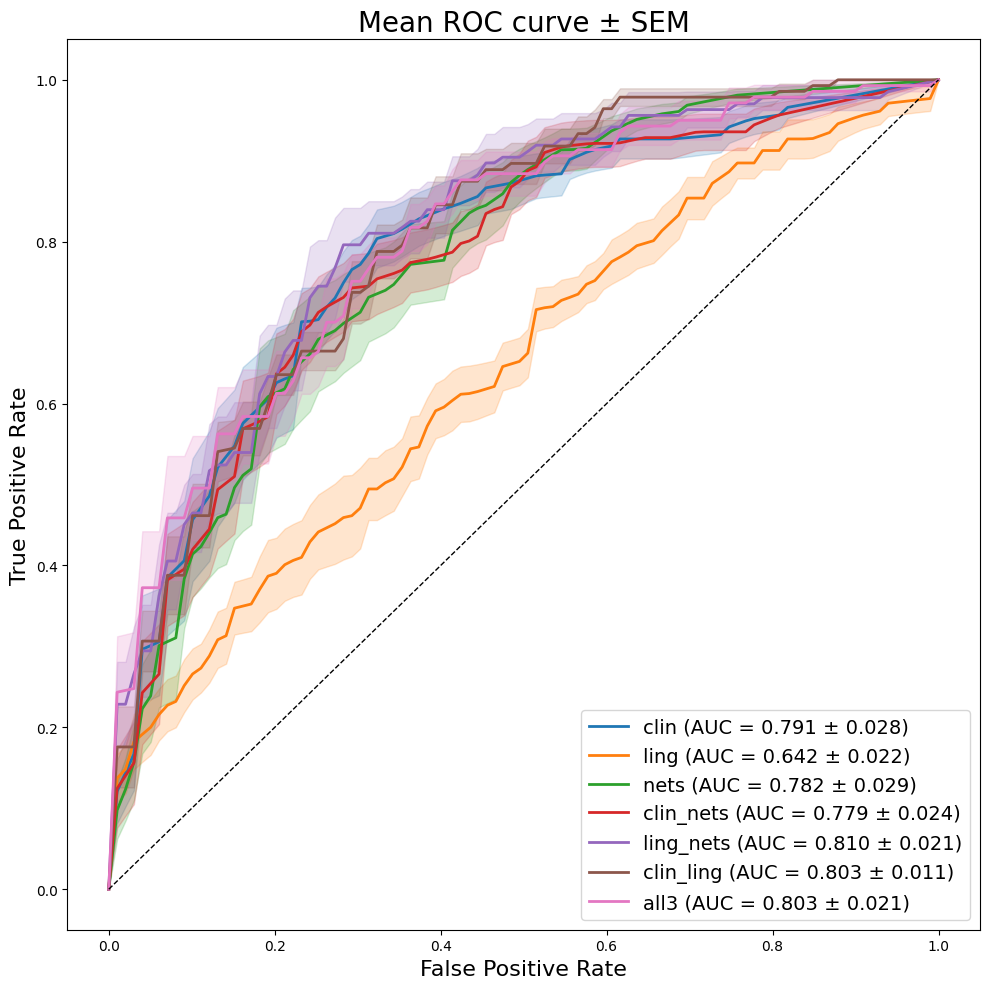

In [ ]:
# Plot ROC curves
plot_roc.plot_mean_rf_roc_sem(rf_models, X_tests, y_tests)


# Bootstrap Metrics

In [ ]:
rf_models = {
    "clin": best_rf_clin,
    "ling": best_rf_ling,
    "nets": best_rf_nets,
    "clin_nets": best_rf_clin_nets,
    "ling_nets": best_rf_ling_nets,
    "clin_ling": best_rf_clin_ling,
    "all3": best_rf_all3
}

X_dict = {
    "clin": X_clin,
    "ling": X_ling,
    "nets": X_nets,
    "clin_nets": X_clin_nets,
    "ling_nets": X_ling_nets,
    "clin_ling": X_clin_ling,
    "all3": X_all3
}

y_dict = {
    "clin": y_clin,
    "ling": y_ling,
    "nets": y_nets,
    "clin_nets": y_clin_nets,
    "ling_nets": y_ling_nets,
    "clin_ling": y_clin_ling,
    "all3": y_all3
}

In [ ]:
results_df = plot_metrics.evaluate_all_models_parallel(rf_models, X_dict, y_dict, n_partitions=500, n_jobs=-1)
plot_metrics.plot_grouped_violin(results_df)

AttributeError: module 'Functions.plot_bootstrap_metrics' has no attribute 'evaluate_all_models_parallel'

In [ ]:
results_df.to_excel("RF_Bootstrap_baseline.xlsx")

# Shap Dependence Plots

In [ ]:
# --- Get top 25 features and SHAP values for Clin + Ling ---
top25_clin_ling, shap_vals_clin_ling, explainer_clin_ling = plot_shap.get_top_shap_features(
    X_clin_ling, best_rf_clin_ling, n_features=25, model_name="Clin + Ling"
)

# --- Get top 25 features and SHAP values for All3 ---
top25_all3, shap_vals_all3, explainer_all3 = plot_shap.get_top_shap_features(
    X_all3, best_rf_all3, n_features=25, model_name="All3"
)

# --- Get full set (e.g. 99 features) if you want a broader SHAP base ---
top_all3, shap_vals_top_all3, explainer_all3 = plot_shap.get_top_shap_features(
    X_all3, best_rf_all3, n_features=99, model_name="All3"
)


In [ ]:
# --- Plot Clin + Ling top 25 SHAP dependence plots ---
plot_shap.plot_shap_dependence_for_features(
    X_clin_ling,
    shap_vals_clin_ling,
    top25_clin_ling,
    model_name="Clin + Ling",
    save_dir="plots/Clin_Ling",
    n_jobs=-1
)

# --- Combine top features from both models (unique order-preserving merge) ---
combined = list(dict.fromkeys(top25_clin_ling + top25_all3))

# --- Plot combined SHAP dependence plots using All3 model values ---
plot_shap.plot_shap_dependence_for_features(
    X_all3,
    shap_vals_top_all3,
    combined,
    model_name="All3",
    save_dir="plots/All3",
    n_jobs=-1
)

# Stat Tests